# Кейс для продуктовых аналитиков
Датасет содержит отзывы действующих клиентов Т-Банка о качестве продуктов, услуг и клиентского сервиса.
## Колонки:
1. `review_dttm` - Дата и время начала отзыва (момент публикации или обращения)
2. `finish_dttm` - Дата и время завершения обработки отзыва (решения вопроса)
3. `id_client` - Уникальный идентификатор клиента (если известен)
4. `company` - Направление, к которому относится отзыв: банк, страховая, инвестиции, работа и др.
5. `review_mark` - Оценка, поставленная автором отзыва (если указана)
6. `review_emotion` - Эмоциональная окраска отзыва: позитивный, нейтральный, негативный
7. `review_source` - Платформа, с которой поступил отзыв: Banki.ru, ВКонтакте, Одноклассники и т.д.
8. `business_line` - Бизнес-линия, указанная в отзыве (например, кредит наличными, депозитные продукты)
9. `product` - Конкретный продукт, о котором идет речь (например, ипотека, дебетовая карта, вклад)
10. `reason` - Причина обращения (например, встречи, неверная консультация)
11. `review_theme` - Тематика отзыва (например, сервис, условия кредита, мобильное приложение)
12. `subtheme` - Подтема отзыва (более детализированная категория, например: «ошибка входа в приложение»)
13. `review_text` - Полный текст отзыва клиента или комментатора
14. `solution_flg` - Флаг: была ли решена проблема клиента
15. `gender_cd` - Пол клиента (если автор — клиент и данные доступны)
16. `education_level_cd` - Уровень образования клиента
17. `marital_status_cd` - Семейное положение
18. `children_cnt` - Количество детей у клиента
19. `citizenship_country` - Гражданство клиента
20. `segment_name` - Клиентский сегмент (например, Доходный, Защищенный)
21. `subscription_important_flg` - Флаг наличия подписки «Премиум» или «Прайват» (1 — есть)
22. `new_flg` - Флаг нового клиента: первый продукт открыт не более 3 месяцев назад (1 — новый)
23. `influencer_flg` - Флаг VIP клиента
24. `age_segment` - Возрастная группа клиента (например, молодежь, взрослые, сеньоры)
25. `csat_score` - Уровень удовлетворенности клиента (Customer Satisfaction Score), рассчитанный на основе отзыва

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('~/Downloads/tbank_case.csv', sep=';')
df.head(10)

,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,...,education_level_cd,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score
0,2025-02-18 15:41:00,2025-02-18 16:56:49,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,...,NaN,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN
1,2025-03-24 20:06:00,2025-03-28 17:42:40,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,...,NaN,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-08 07:40:43,2025-07-08 10:29:05,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,GRD,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN
3,2025-08-07 22:51:48,2025-08-08 09:35:35,5ca669878eaf593f68c10e163246357b,SME,5,Позитивный,banki.ru,sme,расчетный счет,Не определено,...,GRD,MAR,0.0,РФ,Высокодоходные без ПМ,0.0,0.0,1.0,Взрослые,NaN
4,2025-02-13 21:38:40,2025-02-14 08:04:45,7a436100b113ce78c8a7a02974521a16,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,NaN,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Сеньоры,NaN
5,2025-02-24 17:48:47,2025-02-24 18:34:07,e60a8b542d1ffdfd980e0cd330f9d382,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,NaN,NaN,NaN,РФ,Малодоходные,0.0,0.0,0.0,Подростки,NaN
6,2025-02-17 12:14:00,2025-02-17 14:58:27,060308edb7cfda819b61a123511148f0,Банк,без оценки (негативный),Негативный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,GRD,DIV,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,2.0
7,2025-04-06 08:40:00,2025-04-06 13:34:05,73fe1fda01a23a7742ad77310f1f0db3,Банк,1,Негативный,banki.ru,кредит наличными под залог,кредит наличными под залог недвижимости,Не определено,...,GRD,UNM,NaN,РФ,Доходные,0.0,0.0,0.0,Не определен,NaN
8,2025-09-17 20:42:00,2025-09-18 08:50:17,770f72bc2b6348c3469e0b1c873d4676,Инвест,5,Позитивный,banki.ru,инвестиции,брокерский счет,Не определено,...,NaN,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Взрослые,NaN
9,2025-09-25 02:49:00,2025-09-25 10:46:05,8c950261c1fd8973e30954751f4af3a5,SME,5,Позитивный,sravni.ru,sme,расчетный счет,Не определено,...,SCH,MAR,0.0,РФ,Доходные,0.0,0.0,0.0,Взрослые,NaN


In [61]:
df.shape

(56820, 25)

# 1. Exploratory Data Analysis

In [4]:
# Описательные статистики для числовых признаков
df.describe(exclude='object')

,children_cnt,subscription_important_flg,new_flg,influencer_flg,csat_score
count,43342.000000,43608.000000,43608.000000,43608.000000,3407.000000
mean,0.074431,0.038617,0.021602,0.324642,1.619313
std,0.357650,0.192682,0.145380,0.468246,1.354322
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,1.000000,1.000000
max,6.000000,1.000000,1.000000,1.000000,5.000000


In [5]:
# Описательные статистики для категориальных признаков
df.drop('id_client', axis=1).describe(include='object')

,review_dttm,finish_dttm,company,review_mark,review_emotion,review_source,business_line,product,reason,review_theme,subtheme,review_text,solution_flg,gender_cd,education_level_cd,marital_status_cd,citizenship_country,segment_name,age_segment
count,56820,56726,56820,56820,56820,56820,56820,56820,56820,56820,56820,54723,56820,56495,24992,37976,56699,43608,46053
unique,55534,56609,7,8,2,20,26,72,190,30,247,54075,2,2,6,5,63,5,6
top,2025-01-25 08:24:00,2025-05-15 08:11:05,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,тарифы и условия,консультация по продукту,Недавно (08.02.2025) обратилась в Т-Банк за по...,не указано,M,GRD,UNM,РФ,Доходные,Взрослые
freq,16,2,34356,33785,34522,48224,19144,18637,52452,14080,9605,9,43661,33364,15006,20126,55672,22157,25088


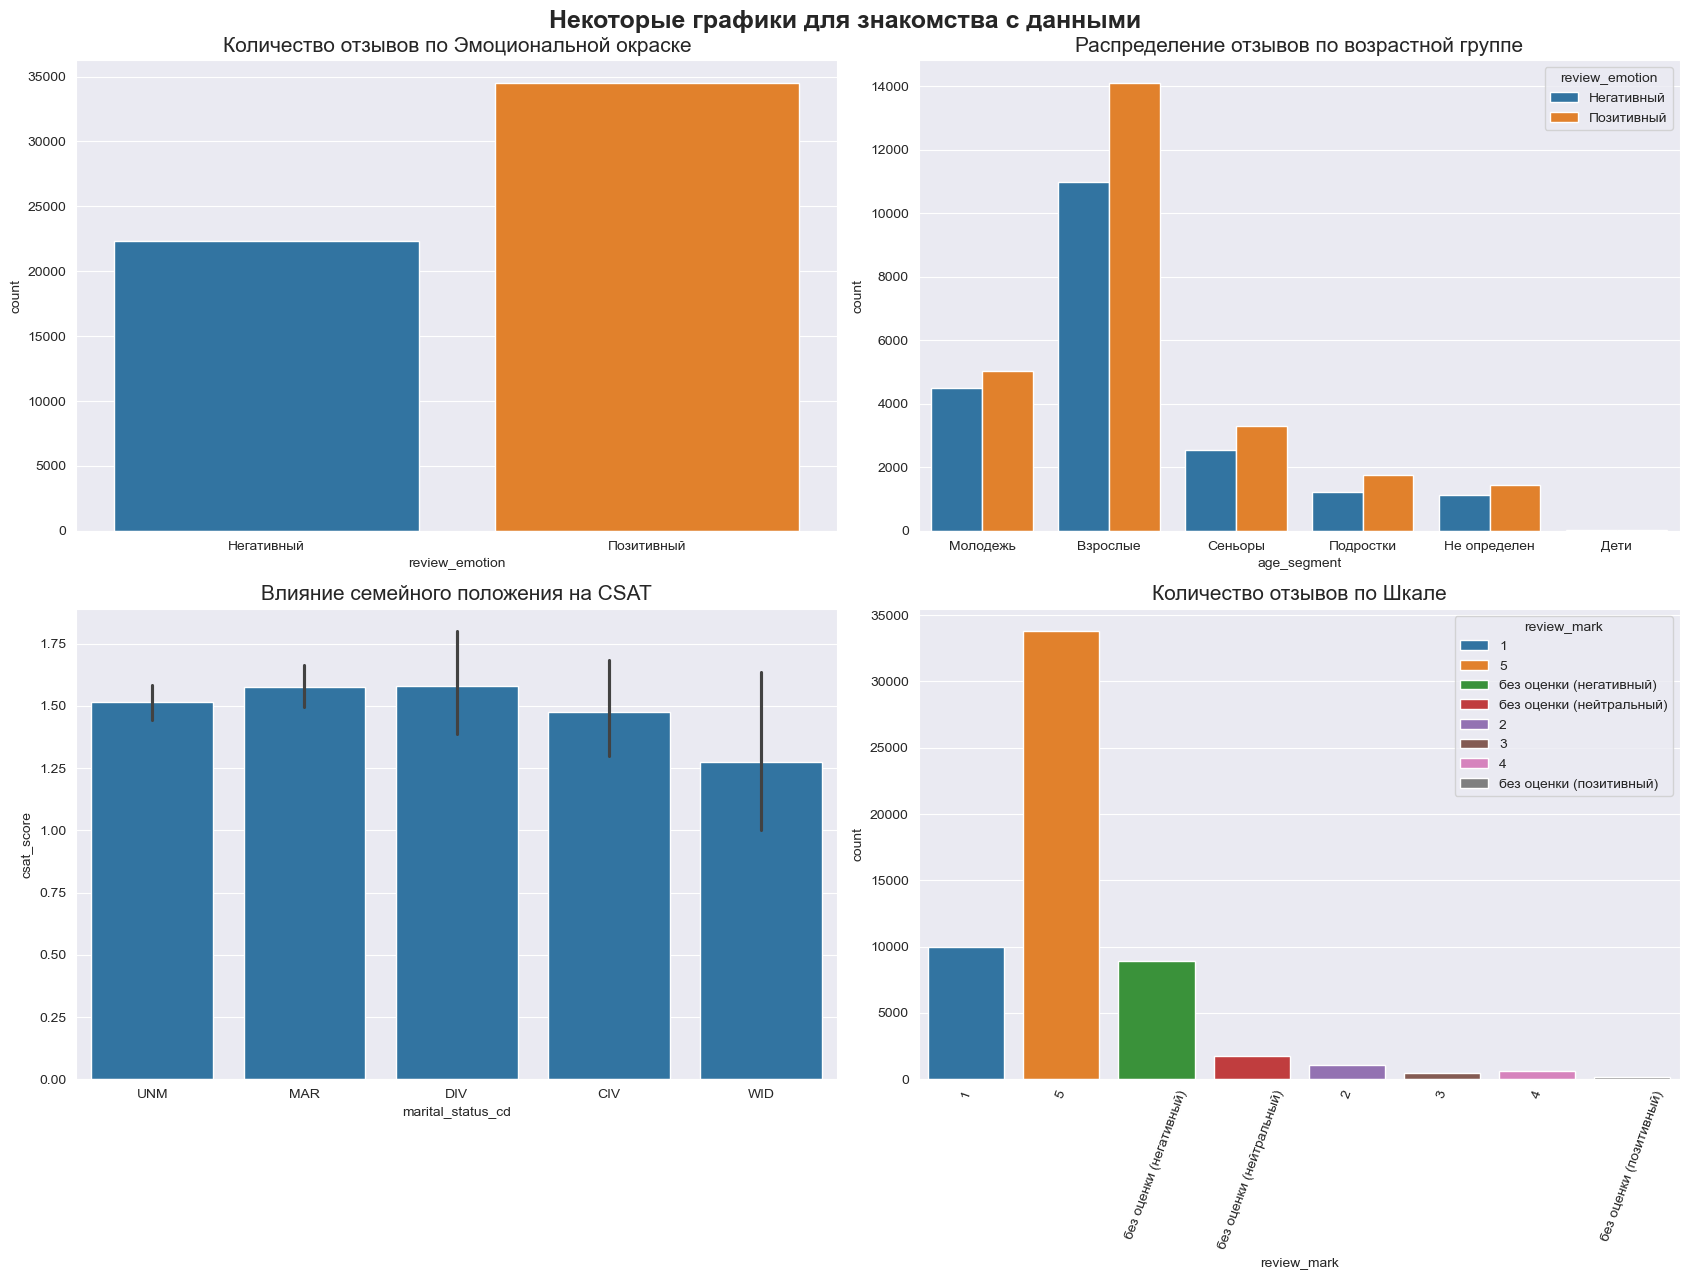

In [63]:
fig, ax = plt.subplots(2, 2, figsize=(17, 13))

fig.suptitle('Некоторые графики для знакомства с данными', fontsize=18, weight='bold')

ax[0][0].set_title('Количество отзывов по Эмоциональной окраске', fontsize=15)
sns.countplot(x=df['review_emotion'], hue=df['review_emotion'], ax=ax[0][0]);

ax[1][1].set_title('Количество отзывов по Шкале', fontsize=15)
sns.countplot(x=df['review_mark'], hue=df['review_mark'], ax=ax[1][1], legend=True);
ax[1][1].tick_params(axis='x', rotation=70)

ax[1][0].set_title('Влияние семейного положения на CSAT', fontsize=15)
sns.barplot(x=df['marital_status_cd'], y=df['csat_score'], ax=ax[1][0])

ax[0][1].set_title('Распределение отзывов по возрастной группе', fontsize=15)
sns.countplot(x=df['age_segment'], hue=df['review_emotion'], ax=ax[0][1]);

plt.subplots_adjust(hspace=0.6)
plt.tight_layout()

# 2. Исследование на предмет выявления уязвимых мест - Постановка задачи и этапы

## Гипотезы
1. Продукты с массовым спросом (дебетовые карты, кредиты наличными) имеют низкую долю негатива, несмотря на большое количество отзывов
2. Основные подтемы негатива различаются по продуктам

## Какие продукты имеют наибольшую долю негативных отзывов и какие подтемы являются причинами недовольства в этих продуктах?

1. Постараюсь найти проблемные продукты, исходя из отзывов. Для этого мне необходимо построить график, который будет показывать количество `Негативных/Позитивных` отзывов на тот или иной продукт. Использую сводные таблицы `pd.crosstab()`
2. Найду топ 15 самых проблемных продуктов по доле негативных отзывов. Тут важно смотреть именно на долю негативных отзывов, а не на количество.
3. Посмотрю на `subtheme` для негативных отзывов у нескольких продуктов. Это позволит ближе ознакомиться именно с причинами негатива со стороны пользователей.



## 2.0 Сводная таблица Типов отзывов по Продукту - Основная таблица, на которую необходимо ориентироваться во время исследования

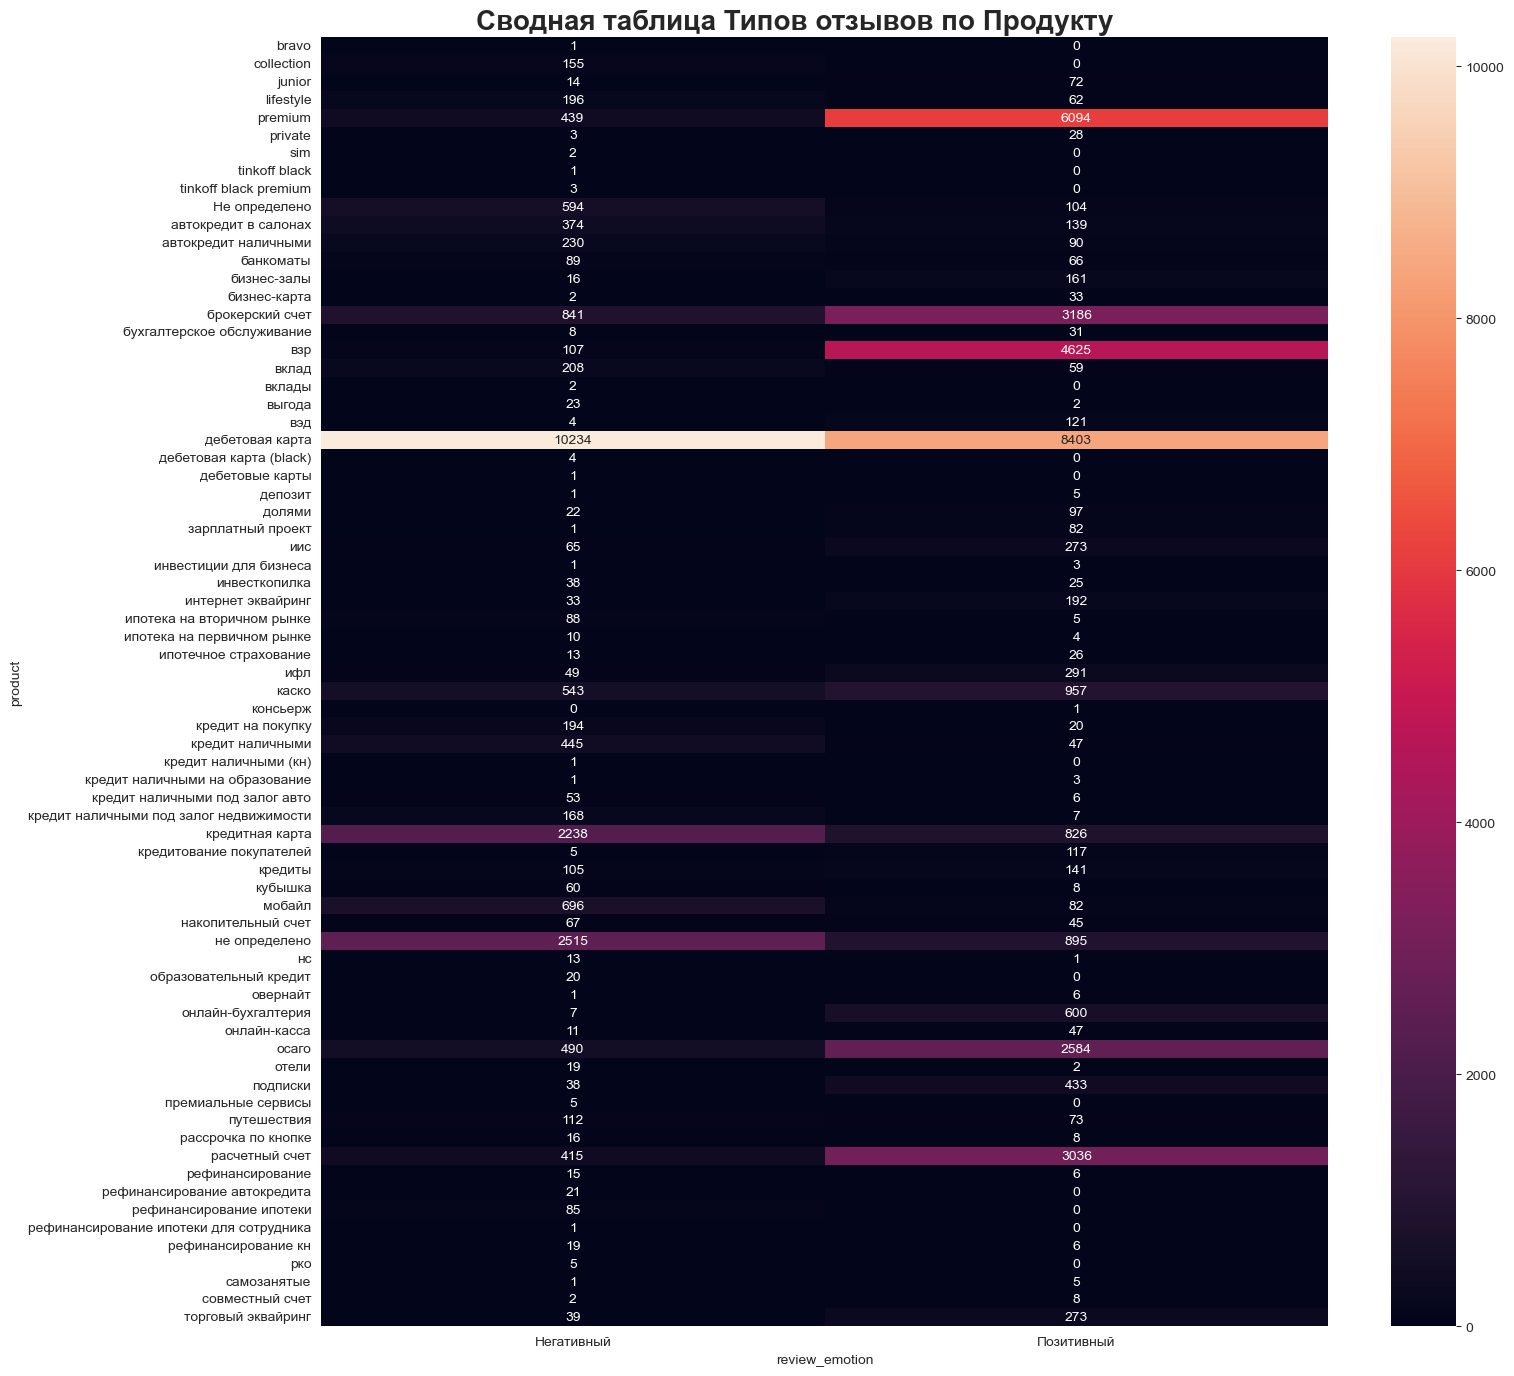

In [62]:
product_to_review = pd.crosstab(df['product'], df['review_emotion'])

plt.figure(figsize=(16, 14))
plt.suptitle('Сводная таблица Типов отзывов по Продукту', fontsize=20, weight='bold')
sns.heatmap(product_to_review, annot=True, fmt='g')

plt.tight_layout();

## 2.1 Проверка H1 - Продукты с массовым спросом имеют низкую долю негатива, так как это популярные продукты с бесперебойной организацией процессов.
1. Найду топ 5 "массовых" продуктов на основе количества отзывов
2. Найду долю негативных отзывов для этих продуктов

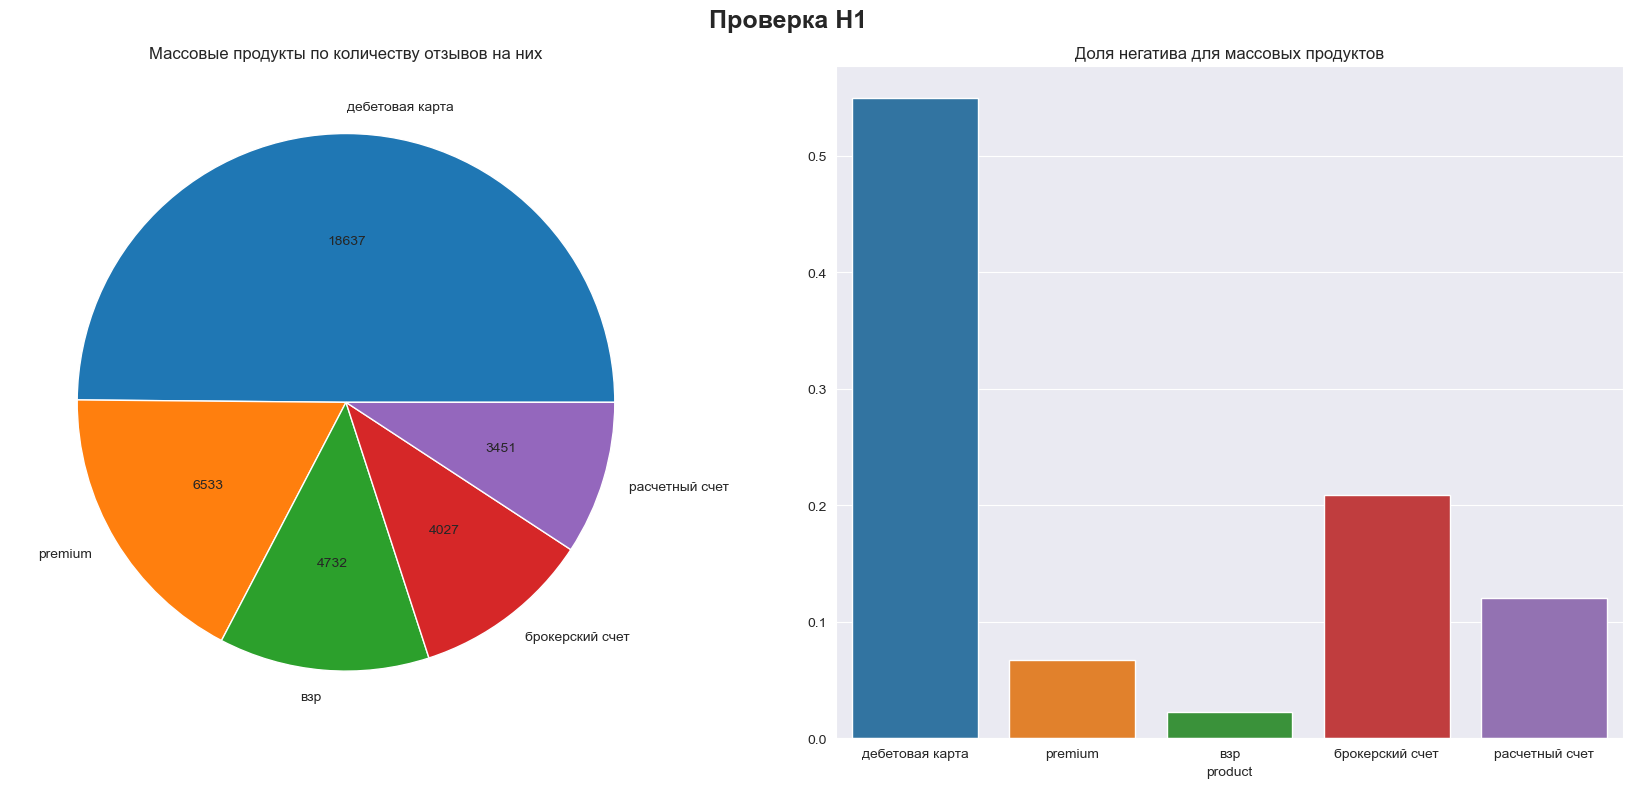

In [64]:
mass_product = df.groupby('product')['review_emotion'].count().sort_values(ascending=False)[:5]

fig, ax = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle('Проверка H1', fontsize=18, weight='bold')

ax[0].set_title('Массовые продукты по количеству отзывов на них', fontsize=12)
ax[0].pie(mass_product, labels=mass_product.index, autopct=lambda p: f'{int(round(p * sum(mass_product) / 100))}')

ax[1].set_title('Доля негатива для массовых продуктов', fontsize=12)
mask = pd.crosstab(df['product'][df['product'].isin(mass_product.index)], df['review_emotion'])
mask = mask['Негативный'].filter(mass_product.index) / mass_product
sns.barplot(x=mask.index, y=mask.values, hue=mask.index, ax=ax[1])

fig.tight_layout()

In [14]:
mass_product

product
дебетовая карта    18637
premium             6533
взр                 4732
брокерский счет     4027
расчетный счет      3451
Name: review_emotion, dtype: int64

### Таким образом, первая гипотеза ОТВЕРГАЕТСЯ. Исходя из визуализации, мы видим, что у некоторых "массовых" продуктов доля негативных отзывов составляет 20%, а то и более 50%. Даже у популярных продуктов с, казалось бы, бесперебойной организацией процессов имеются проблемы. Стоит обратить внимание на продукт - `Дебетовая карта`.

## 2.2 Проверка H2 - Основные подтемы негативных отзывов отличаются по продуктам.
1. Найду топ 15 продуктов с наибольшей долей негативных отзывов
2. На основе этих продуктов выделю категории продуктов - `Карты`, `Кредиты`, `Счета`
3. По этим категориям построю графики для поиска самых популярных подтем в негативных отзывах
4. Систематизирую полученные результаты

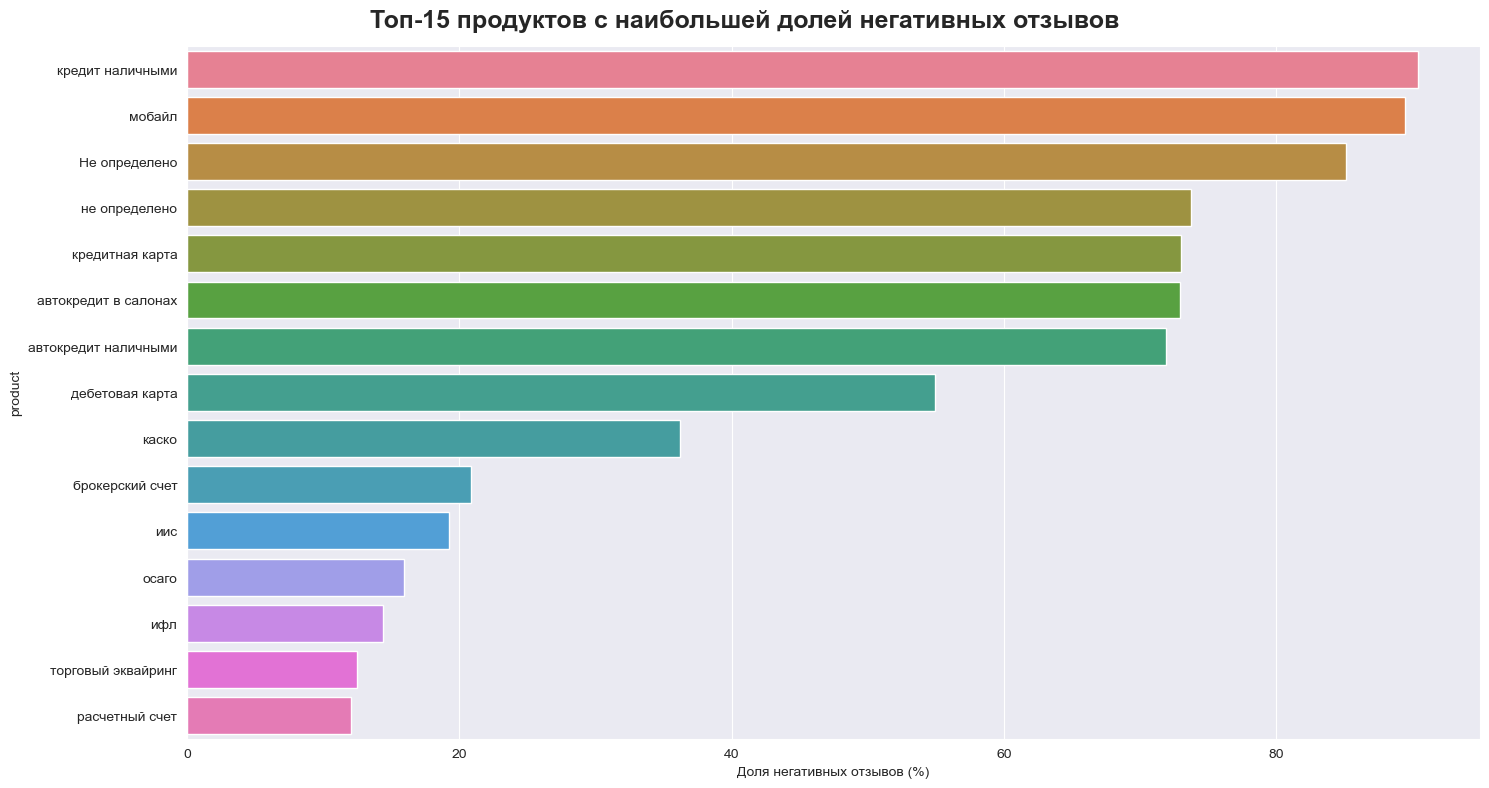

In [65]:
product_to_review['total_reviews'] = product_to_review['Негативный'] + product_to_review['Позитивный']
product_to_review['neg_share'] = product_to_review['Негативный'] / product_to_review['total_reviews'] * 100

product_to_review_filtered = product_to_review[product_to_review['total_reviews'] >= 300]

mask = product_to_review_filtered['neg_share'].sort_values(ascending=False).head(15)

plt.figure(figsize=(15, 8))
plt.suptitle('Топ-15 продуктов с наибольшей долей негативных отзывов', fontsize=18, weight='bold')
sns.barplot(x=mask.values, y=mask.index, hue=mask.index)
plt.xlabel('Доля негативных отзывов (%)')

plt.tight_layout();

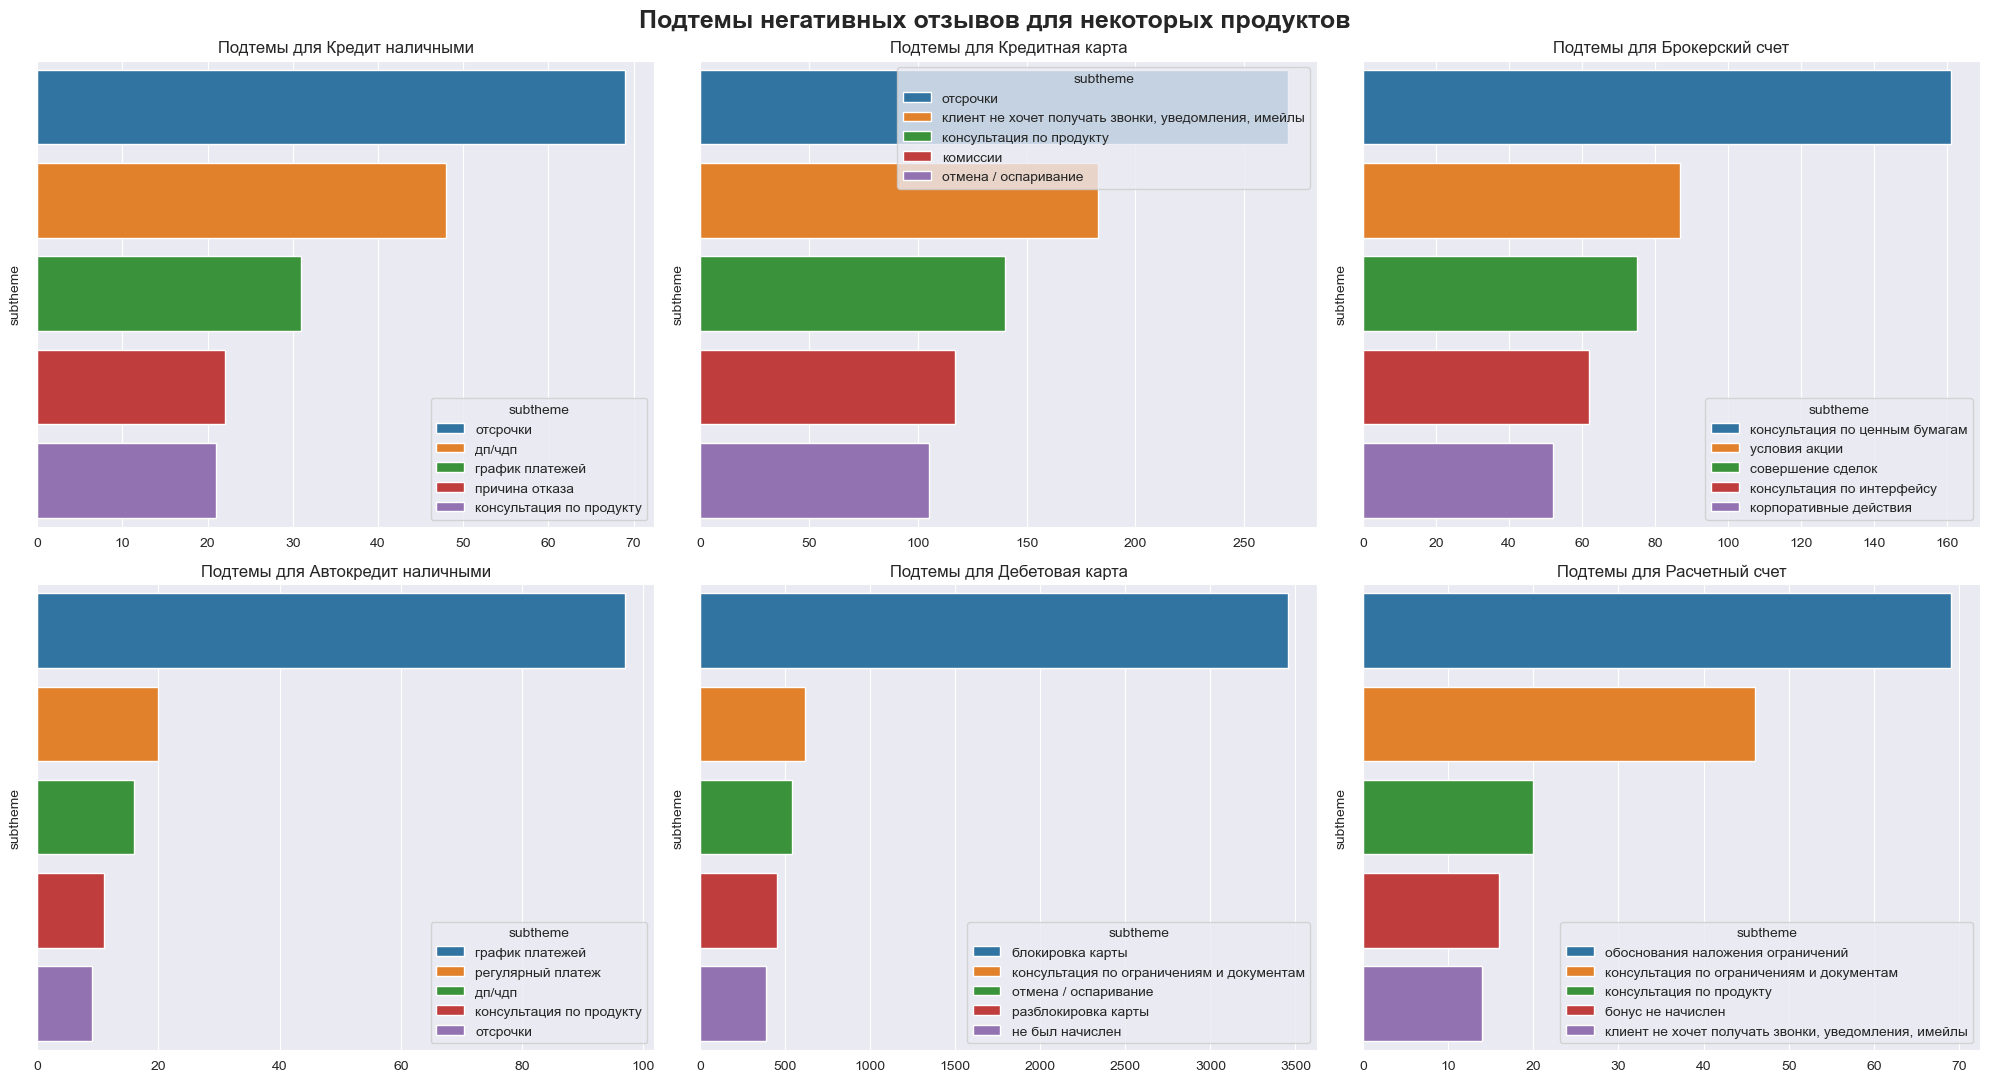

In [67]:
fig, ax = plt.subplots(2, 3, figsize=(20, 11))

fig.suptitle('Подтемы негативных отзывов для некоторых продуктов', fontsize=18, weight='bold')

ax[0][0].set_title('Подтемы для Кредит наличными', fontsize=12)
mask = df['subtheme'][(df['product'] == 'кредит наличными') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[0][0], legend=True)
ax[0][0].set_yticklabels([])

ax[0][1].set_title('Подтемы для Кредитная карта', fontsize=12)
mask = df['subtheme'][(df['product'] == 'кредитная карта') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[0][1], legend=True)
ax[0][1].set_yticklabels([])

ax[1][0].set_title('Подтемы для Автокредит наличными', fontsize=12)
mask = df['subtheme'][(df['product'] == 'автокредит наличными') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[1][0], legend=True)
ax[1][0].set_yticklabels([])

ax[1][1].set_title('Подтемы для Дебетовая карта', fontsize=12)
mask = df['subtheme'][(df['product'] == 'дебетовая карта') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[1][1], legend=True)
ax[1][1].set_yticklabels([]);

ax[0][2].set_title('Подтемы для Брокерский счет', fontsize=12)
mask = df['subtheme'][(df['product'] == 'брокерский счет') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[0][2], legend=True)
ax[0][2].set_yticklabels([]);

ax[1][2].set_title('Подтемы для Расчетный счет', fontsize=12)
mask = df['subtheme'][(df['product'] == 'расчетный счет') & (df['review_emotion'] == 'Негативный')].value_counts()[:5]
sns.barplot(x=mask.values, y=mask.index, hue=mask.index, ax=ax[1][2], legend=True)
ax[1][2].set_yticklabels([]);

fig.tight_layout()

### Таким образом, вторая гипотеза ПОДТВЕРЖДАЕТСЯ. Анализ по 6 продуктам показал, что причины недовольства существенно различаются в зависимости от категорий продукта.
1. Кредитные продукты
    1. Основные проблемы связаны с графиком платежей, отсрочками и ДП/ЧДП
    2. Клиенты нуждаются в консультациях по продукту
2. Кредитная и Дебетовая карты
    1. Проблемы технического характера
    2. Также есть необходимость в консультациях
3. Брокерский и Расчетный счет
    1. Основные проблемы - консультации по продуктам

# Итоги

## 1. Краткое резюме
Проведен анализ 56820 отзывов клиентов банка с целью выявления уязвимых мест в продуктах. Дополнительно было проверено 2 гипотезы:
1. Массовые продукты имеют низкую долю негативных отзывов
2. Основные подтемы негатива различаются по продуктам

## 2. Результаты по гипотезам
### Гипотеза H1 **Отвергнута**
Анализ показал, что у некоторых массовых продуктов доля негативных отзывов превышает 50%. Дебетовая карта — самый массовый продукт с наибольшим количеством отзывов и одновременно критической долей негатива (51%). Это означает, что 10 234 клиента недовольны основным продуктом банка. Популярность продукта НЕ гарантирует его качество. Массовые продукты требуют не меньшего внимания, чем нишевые.

### Гипотеза H2 **Подтверждена**
Анализ топ-6 продуктов показал, что у каждой категории свои уникальные болевые точки. Нельзя применять единый подход к улучшению всех продуктов.
1. Кредитные продукты
    1. Основные проблемы связаны с графиком платежей, отсрочками и ДП/ЧДП
    2. Клиенты нуждаются в консультациях по продукту
2. Кредитная и Дебетовая карты
    1. Проблемы технического характера
    2. Также есть необходимость в консультациях
3. Брокерский и Расчетный счет
    1. Основные проблемы - консультации по продуктам


Таким образом, каждая категория требует комплексных решений.